In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def initial_condition(x):
    u = np.zeros_like(x)
    for i in range(len(x)):
        if x[i] <= 0.5:
            u[i] = 2 * x[i]
        else:
            u[i] = 2 - 2 * x[i]
    return u

In [4]:
dx = 0.05
x_max = 1.0
t_max = 0.06
x_b = np.arange(0, x_max + dx / 2, dx)
Nx = len(x_b)

In [5]:
dt_b = 0.0013
t_b = np.arange(0, t_max + dt_b, dt_b)
Nt_b = len(t_b)

u_b = np.zeros((Nt_b, Nx))
u_b[0, :] = initial_condition(x_b)
alpha_b = dt_b / (dx**2)

In [6]:
for k in range(0, Nt_b - 1):
    for i in range(1, Nx - 1):
        u_b[k + 1, i] = u_b[k, i] + alpha_b * (
            u_b[k, i + 1] - 2 * u_b[k, i] + u_b[k, i - 1]
        )

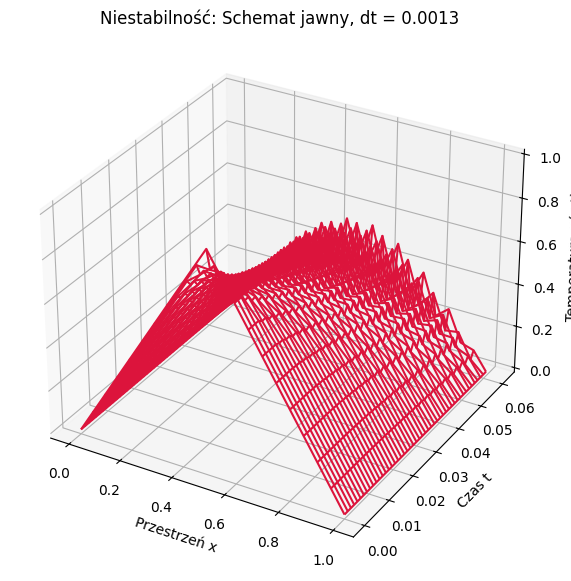

In [7]:
fig1 = plt.figure(figsize=(10, 7))
ax1 = fig1.add_subplot(111, projection="3d")
X_b, T_b = np.meshgrid(x_b, t_b)
ax1.plot_wireframe(X_b, T_b, u_b, color="crimson")
ax1.set_xlabel("Przestrzeń x")
ax1.set_ylabel("Czas t")
ax1.set_zlabel("Temperatura u(x,t)")
ax1.set_title("Niestabilność: Schemat jawny, dt = 0.0013")
plt.show()